# Water Quality in a Drinking Water Distribution Network

## Learning Objectives

- Describe a branched distribution network as a rooted tree with time-constant geometry and time-varying demand
- Derive the arrival time at a tap by chaining each pipe's displacement condition, without assuming steady flow
- See why a *shared trunk main* counts in full for every downstream path, never divided among them
- Track a contamination pulse and a chlorine residual from the treatment plant to individual taps
- Reconstruct the produced water quality from measurements at a handful of taps

## Overview

A branched distribution network has exactly one path from the treatment plant to each delivery
point, and a junction that *splits* flow leaves concentration unchanged. Everything a tap
receives is therefore the produced water, delayed — and the delay follows from how much water
has to be pushed through each pipe on the way.

That is the entire model. It needs no hydraulic solver, no time stepping, and no assumption
that the demand pattern is steady.

### Key assumptions

- **Tree topology, single source.** Flow splits but never merges. A merge blends two transport
  histories that a single-source model cannot represent.
- **Plug flow.** No axial mixing inside a pipe. Good for turbulent mains; optimistic for thin,
  low-flow service lines.
- **No storage.** The network holds only the fixed water volume of its pipes — no tanks.
- **Forward flow.** Every segment carries non-negative flow throughout the record.

## Theoretical background

### The displacement condition

A pipe of water volume $V$ carrying throughflow $Q(t)$ is a queue: a parcel that enters at time
$s$ leaves once exactly $V$ of water has passed it. With the pipe's own cumulative volume
$C(t)=\int^t Q$,

$$C(t_\mathrm{out}) = C(t_\mathrm{in}) + V .$$

Piecewise-constant $Q$ makes $C$ piecewise linear, so this map and its inverse are *exact* — no
discretisation error, whatever the flow does.

### Chaining the pipes

The arrival time at a tap is the composition of these maps along its path, each pipe inverting
*its own* cumulative volume. Nothing in the chain assumes that a segment carries a fixed share of
the production, which is what lets demands move independently.

### The special case that collapses

If every segment does carry a constant fraction $f_i$ of the production $Q_0$, then
$C_i = f_i C_0$ and the chain telescopes:

$$\int_{t_\mathrm{in}}^{t_\mathrm{out}} Q_0(t)\,\mathrm{d}t
   \;=\; \sum_{i \in \mathrm{path}} \frac{V_i}{f_i} \;\equiv\; V_\mathrm{eff}.$$

One number per path, in units of plant throughflow. Note the denominator: it is the segment's
*own* fraction, so the trunk main ($f=1$) contributes its **full** volume to every downstream
path. Slice the trunk lengthwise into virtual sub-tubes, one per tap, sized in proportion to the
share $f_j$ that tap will draw: sub-tube $j$ holds $f_j V_0$ and carries $f_j Q_0$, so its
transit costs $V_0$ of plant throughflow — the same for all of them.

This notebook uses that closed form as a *reference*, and shows where it stops being right.

### Reading the output

Concentration at a tap is reported as the flow-weighted average over each output bin. The
package gets that for free by working in the **cumulative throughflow volume at the tap** rather
than in time: a uniform average in that coordinate *is* a flow-weighted average in time.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pipetransport import plot, residence_time
from pipetransport.examples import example_demand, example_network
from pipetransport.logremoval import segment_decay_rate
from pipetransport.network import PipeNetwork
from pipetransport.transport import endmember_to_source, source_to_endmember
from pipetransport.utils import step_plot_coords

plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["axes.facecolor"] = "#fcfcfb"
INK, INK_SOFT = "#0b0b0b", "#52514e"

print("Libraries imported successfully")

Libraries imported successfully


## 1. The network

A treatment plant feeds a 400 mm trunk main that splits into two district mains, each serving two
monitoring points. Pipe water volume follows from the inner diameter and length.

In [2]:
network = example_network()
volume = network.segments["volume"]

print(network)
print()
print(network.segments.round(2))

PipeNetwork(source='Plant', segments=7, endmembers=4, volume=473.2 m3)

          from  to  length  diameter  volume
Plant-A  Plant   A  2000.0      0.40  251.33
A-B          A   B  1500.0      0.30  106.03
A-C          A   C  1200.0      0.25   58.90
B-T1         B  T1   800.0      0.15   14.14
B-T2         B  T2   400.0      0.20   12.57
C-T3         C  T3   600.0      0.15   10.60
C-T4         C  T4  2500.0      0.10   19.63


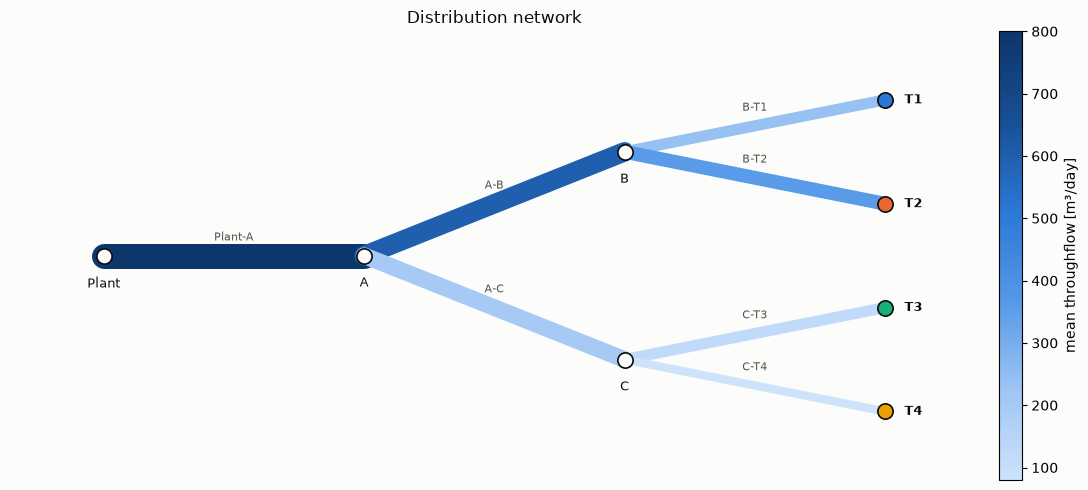

In [3]:
tedges = pd.date_range("2025-06-01", "2025-06-15", freq="h")  # n+1 edges for n hourly bins
demand = example_demand(tedges=tedges, network=network)  # m3/day, one column per tap
production = demand.sum(axis=1)
segment_flow = network.segment_flow(flow=demand)

fig, ax = plt.subplots(figsize=(11, 5))
plot.network(
    network=network,
    values=pd.Series(segment_flow.mean(axis=1), index=network.segments.index),
    value_label="mean throughflow [m³/day]",
    ax=ax,
)
plt.tight_layout()
plt.show()

T4's path holds 330 m³ of water — *less* than T1's 371 m³ — yet section 3 will show its water is
more than half as old again. Volume alone does not tell you the age; volume *per unit of flow*
does. T4's 2.5 km, 100 mm branch holds only 19.6 m³, but it carries a tenth of the production, so
traversing it costs about 194 m³ of plant throughflow — against 28 m³ for T2's short, well-fed
branch.

## 2. Demand that does not scale together

Households peak in the morning and the evening, a commercial block peaks at midday, and an
industrial user runs a night shift. The share of production each pipe carries therefore moves
through the day.

In [4]:
share = pd.DataFrame(
    (segment_flow / production.to_numpy()).T,
    index=demand.index,
    columns=network.segments.index,
)
spread = pd.DataFrame({
    "mean share [-]": share.mean(),
    "min share [-]": share.min(),
    "max share [-]": share.max(),
})
spread["max / min [-]"] = spread["max share [-]"] / spread["min share [-]"]
print(spread.round(3))

         mean share [-]  min share [-]  max share [-]  max / min [-]
Plant-A           1.000          1.000          1.000          1.000
A-B               0.750          0.707          0.791          1.118
A-C               0.250          0.209          0.293          1.398
B-T1              0.300          0.135          0.467          3.453
B-T2              0.449          0.251          0.646          2.570
C-T3              0.149          0.100          0.198          1.984
C-T4              0.101          0.030          0.174          5.858


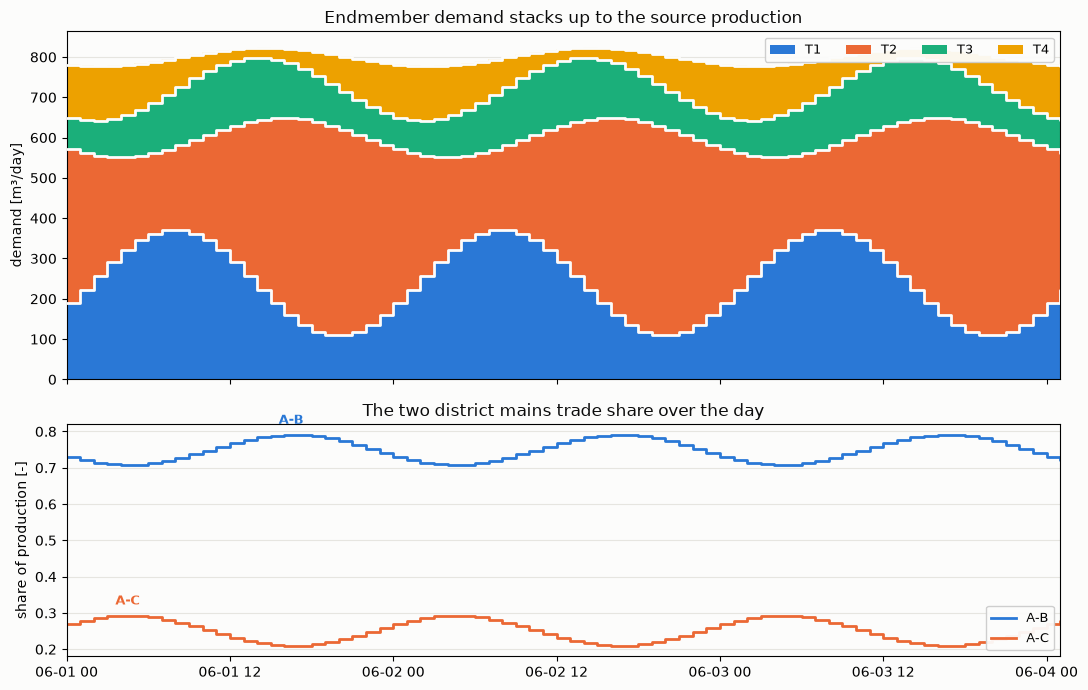

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, height_ratios=[1.5, 1])

plot.flow_allocation(network=network, flow=demand, tedges=tedges, ax=axes[0])
axes[0].set_xlabel("")
axes[0].legend(loc="upper right", ncol=4, fontsize=9, framealpha=0.95)

for name, color in zip(["A-B", "A-C"], plot.series_colors(2), strict=True):
    axes[1].plot(*step_plot_coords(tedges, share[name].to_numpy()), color=color, linewidth=2, label=name)
    axes[1].annotate(
        name,
        xy=(demand.index[share[name].argmax()], share[name].max()),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9.5,
        fontweight="bold",
        color=color,
    )
axes[1].set_ylabel("share of production [-]")
axes[1].set_title("The two district mains trade share over the day", fontsize=12, color=INK)
axes[1].grid(visible=True, axis="y", color="#e6e5e0", linewidth=0.8)
axes[1].set_axisbelow(True)
axes[1].set_xlim(tedges[0], tedges[73])
axes[1].legend(loc="lower right", fontsize=9, framealpha=0.95)

plt.tight_layout()
plt.show()

Over the day the busy district main's share of production moves by 12 % and the quiet one's by
40 %; at the taps themselves the swing reaches a factor of 5.9 for T4. A model that fixes the flow
fractions at their mean has to pick one point on each of these curves and stick to it;
`pipetransport` recomputes the split at every time step, so nothing here needs approximating.

## 3. Water age

Age is the contact time behind every reaction in the network. It follows from the same arrival
map as transport does.

In [6]:
age_hours = residence_time.full(flow=demand, tedges=tedges, network=network) * 24.0

summary = pd.DataFrame(
    {
        "mean demand [m³/day]": demand.mean(),
        "path water volume [m³]": [volume[list(network.paths[tap])].sum() for tap in network.endmembers],
        "min age [h]": np.nanmin(age_hours, axis=1),
        "mean age [h]": np.nanmean(age_hours, axis=1),
        "max age [h]": np.nanmax(age_hours, axis=1),
    },
    index=list(network.endmembers),
)
print(summary.round(2))

    mean demand [m³/day]  path water volume [m³]  min age [h]  mean age [h]  \
T1                 240.0                  371.49        13.08         13.48   
T2                 360.0                  369.92        11.95         12.72   
T3                 120.0                  320.84        15.57         16.97   
T4                  80.0                  329.87        17.97         21.07   

    max age [h]  
T1        14.41  
T2        13.82  
T3        18.65  
T4        25.17  


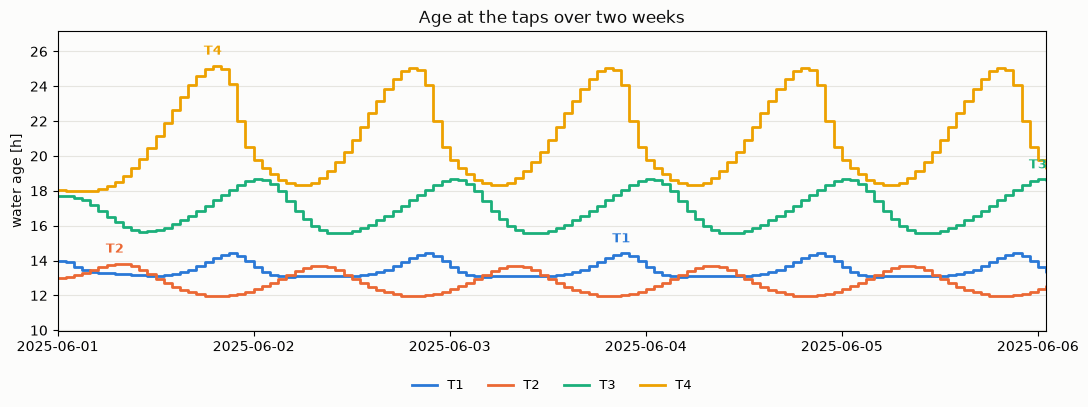

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.2))
plot.endmember_series(
    values=age_hours,
    tedges=tedges,
    labels=list(network.endmembers),
    ylabel="water age [h]",
    title="Age at the taps over two weeks",
    ax=ax,
)
ax.set_xlim(tedges[0], tedges[121])
plt.tight_layout()
plt.show()

T4's age swings from 18 h to 25 h — a 40 % daily excursion — while T1 and T2 move by only 10 % and
16 %. The industrial night shift empties T4's branch quickly and then leaves it nearly stagnant;
the residential taps sit behind mains whose flow is far steadier.

### What the fixed-fraction shortcut costs

The closed form of the theory section — one effective volume $\sum V_i/f_i$ driven by the plant
flow — is exactly what a proportional-demand model computes. Because `pipetransport` can also be
handed a *single* lumped pipe, the comparison is a two-line experiment.

In [8]:
mean_share = share.mean()
effective_volume = {
    tap: float(sum(volume[seg] / mean_share[seg] for seg in network.paths[tap])) for tap in network.endmembers
}

lumped_age = {}
for tap, v_eff in effective_volume.items():
    lumped = PipeNetwork(
        segments=pd.DataFrame({"from": ["Plant"], "to": [tap], "volume": [v_eff]}, index=["lumped"]),
        source="Plant",
    )
    lumped_age[tap] = residence_time.full(flow=production.to_numpy()[None, :], tedges=tedges, network=lumped)[0] * 24.0

comparison = pd.DataFrame({
    "effective volume [m³]": effective_volume,
    "fixed-fraction mean age [h]": {t: np.nanmean(a) for t, a in lumped_age.items()},
    "exact mean age [h]": dict(zip(network.endmembers, np.nanmean(age_hours, axis=1), strict=True)),
    "max error [h]": {
        tap: np.nanmax(np.abs(lumped_age[tap] - age_hours[i])) for i, tap in enumerate(network.endmembers)
    },
})
print(comparison.round(2))

    effective volume [m³]  fixed-fraction mean age [h]  exact mean age [h]  \
T1                 439.84                        13.20               13.48   
T2                 420.78                        12.63               12.72   
T3                 557.41                        16.73               16.97   
T4                 680.85                        20.44               21.07   

    max error [h]  
T1           1.42  
T2           0.90  
T3           2.09  
T4           4.76  


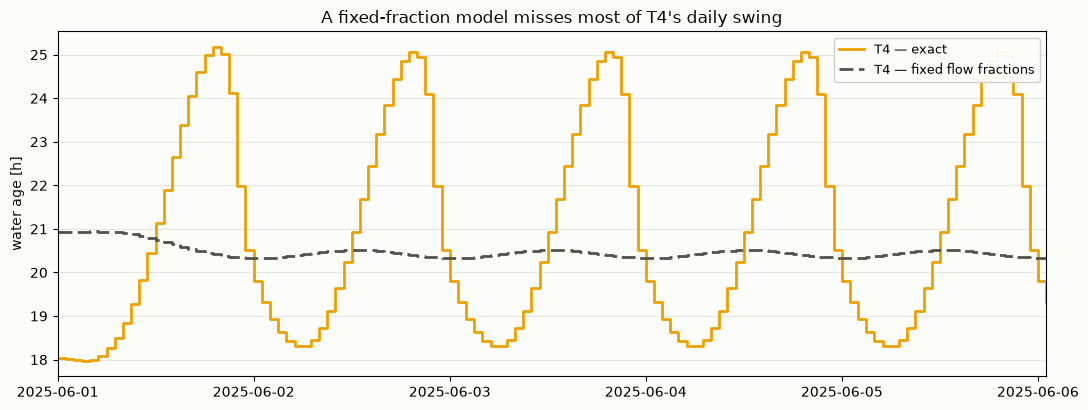

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.2))
colors = plot.series_colors(len(network.endmembers))

ax.plot(*step_plot_coords(tedges, age_hours[3]), color=colors[3], linewidth=2, label="T4 — exact")
ax.plot(
    *step_plot_coords(tedges, lumped_age["T4"]),
    color=INK_SOFT,
    linewidth=2,
    linestyle=(0, (5, 2)),
    label="T4 — fixed flow fractions",
)
ax.set_ylabel("water age [h]", color=INK)
ax.set_title("A fixed-fraction model misses most of T4's daily swing", fontsize=12, color=INK)
ax.set_xlim(tedges[0], tedges[121])
ax.grid(visible=True, axis="y", color="#e6e5e0", linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(loc="upper right", fontsize=9, framealpha=0.95)
plt.tight_layout()
plt.show()

The fixed-fraction curve tracks the plant's own diurnal rhythm, because that is the only thing it
can see. The exact curve is driven by T4's *own* demand, which peaks when the plant's does not.
Averaged over the fortnight the two agree closely; hour by hour they disagree by hours of contact
time — which is exactly the resolution at which a disinfectant residual or a nitrification risk is
assessed.

## 4. A contamination pulse

A three-hour event at the plant travels out to every monitoring point at once.

In [10]:
midpoint = tedges[:-1] + (tedges[1:] - tedges[:-1]) / 2
cin = np.zeros(len(tedges) - 1)
cin[(midpoint >= pd.Timestamp("2025-06-02 06:00")) & (midpoint < pd.Timestamp("2025-06-02 09:00"))] = 1.0

cout = source_to_endmember(cin=cin, flow=demand, tedges=tedges, cout_tedges=tedges, network=network)

above = cout > 0.05
arrival = pd.DataFrame(
    {
        "peak [-]": np.nanmax(cout, axis=1),
        "peak arrival": [midpoint[int(np.nanargmax(row))] for row in cout],
        "first arrival": [midpoint[int(np.argmax(row))] for row in above],
        "duration above 0.05 [h]": above.sum(axis=1),
    },
    index=list(network.endmembers),
)
print(arrival)

    peak [-]        peak arrival       first arrival  duration above 0.05 [h]
T1       1.0 2025-06-02 21:30:00 2025-06-02 20:30:00                        4
T2       1.0 2025-06-02 19:30:00 2025-06-02 18:30:00                        3
T3       1.0 2025-06-03 02:30:00 2025-06-03 00:30:00                        4
T4       1.0 2025-06-03 02:30:00 2025-06-03 01:30:00                        3


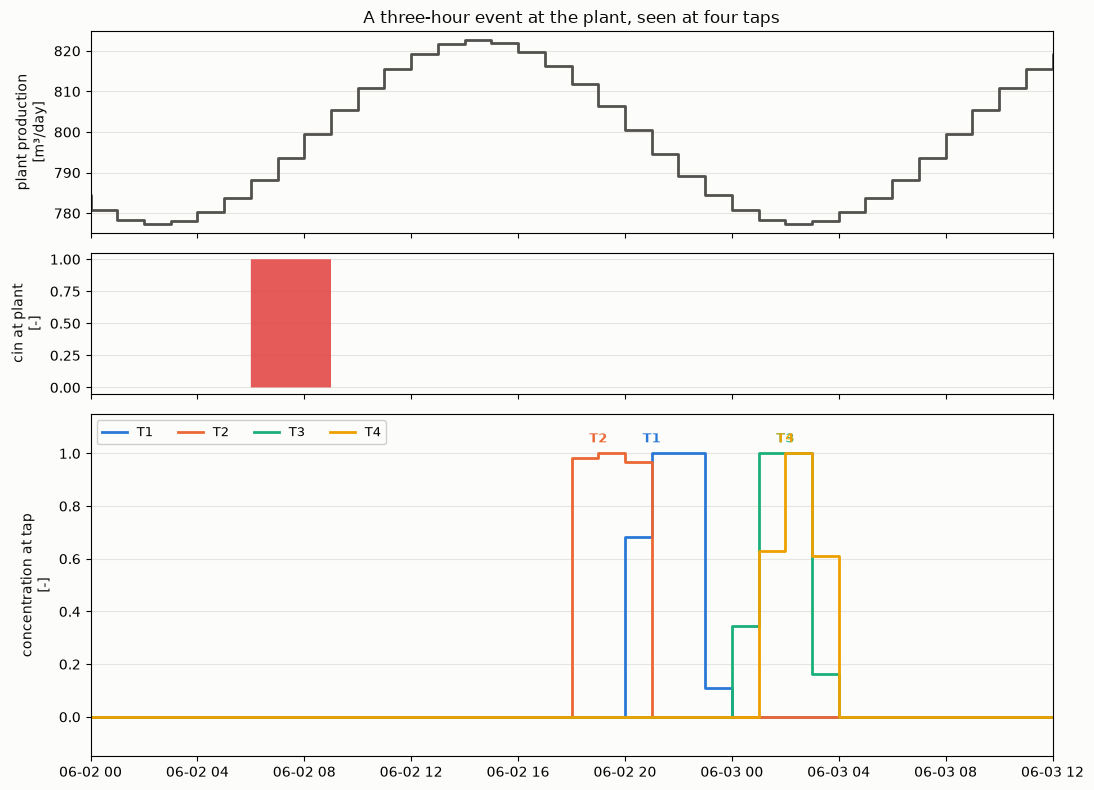

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True, height_ratios=[1, 0.7, 1.7])

axes[0].plot(*step_plot_coords(tedges, production.to_numpy()), color=INK_SOFT, linewidth=2)
axes[0].set_ylabel("plant production\n[m³/day]", color=INK)
axes[0].set_title("A three-hour event at the plant, seen at four taps", fontsize=12, color=INK)

axes[1].fill_between(*step_plot_coords(tedges, cin), color="#e34948", alpha=0.9, linewidth=0)
axes[1].set_ylabel("cin at plant\n[-]", color=INK)

plot.endmember_series(
    values=cout, tedges=tedges, labels=list(network.endmembers), ylabel="concentration at tap\n[-]", ax=axes[2]
)
axes[2].set_xlim(pd.Timestamp("2025-06-02 00:00"), pd.Timestamp("2025-06-03 12:00"))
axes[2].legend(loc="upper left", ncol=4, fontsize=9, framealpha=0.95)
for panel in axes[:2]:
    panel.grid(visible=True, axis="y", color="#e6e5e0", linewidth=0.8)
    panel.set_axisbelow(True)

plt.tight_layout()
plt.show()

All four taps see the pulse at full strength — a split dilutes nothing — but at different times,
and at different *durations*. The three hours of contaminated water spread over four hours at T1
and T3 and stay at three hours at T2 and T4. Whether a release is stretched or compressed depends
on the receiving tap's flow when the water arrives relative to the plant's flow when it left: T4's
industrial demand happens to be peaking when this pulse reaches it, so the same volume is drawn off
faster than it was produced. Plug flow keeps the edges sharp; a real network smears them further,
which section 7 returns to.

## 5. Chlorine residual

Chlorine is consumed in the bulk water and at the pipe wall. The wall term scales with the
surface-to-volume ratio $4/D$, so a 100 mm service line consumes residual four times faster per
hour of contact than a 400 mm trunk main.

In [12]:
decay = segment_decay_rate(network=network, bulk_decay_rate=0.30, wall_decay_rate=0.02)
print(pd.DataFrame({"diameter [m]": network.segments["diameter"], "decay rate [1/day]": decay}).round(3))

dose = np.full(len(tedges) - 1, 1.0)  # mg/L leaving the plant
residual = source_to_endmember(
    cin=dose, flow=demand, tedges=tedges, cout_tedges=tedges, network=network, decay_rate=decay
)

print()
print(
    pd.DataFrame(
        {
            "min residual [mg/L]": np.nanmin(residual, axis=1),
            "mean residual [mg/L]": np.nanmean(residual, axis=1),
            "max residual [mg/L]": np.nanmax(residual, axis=1),
        },
        index=list(network.endmembers),
    ).round(3)
)

         diameter [m]  decay rate [1/day]
Plant-A          0.40               0.500
A-B              0.30               0.567
A-C              0.25               0.620
B-T1             0.15               0.833
B-T2             0.20               0.700
C-T3             0.15               0.833
C-T4             0.10               1.100

    min residual [mg/L]  mean residual [mg/L]  max residual [mg/L]
T1                0.702                 0.729                0.742
T2                0.731                 0.752                0.767
T3                0.624                 0.657                0.685
T4                0.434                 0.531                0.609


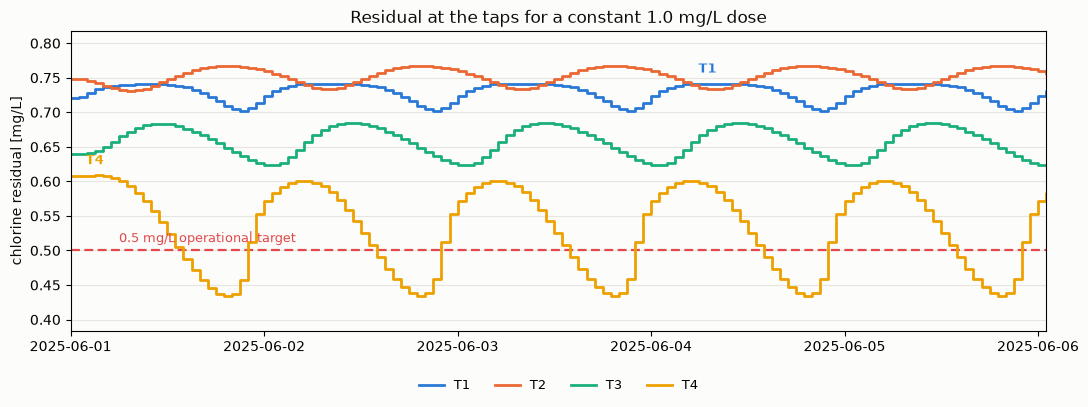

In [13]:
fig, ax = plt.subplots(figsize=(11, 4.2))
plot.endmember_series(
    values=residual,
    tedges=tedges,
    labels=list(network.endmembers),
    ylabel="chlorine residual [mg/L]",
    title="Residual at the taps for a constant 1.0 mg/L dose",
    ax=ax,
)
ax.axhline(0.5, color="#e34948", linewidth=1.6, linestyle=(0, (4, 2)), zorder=1)
ax.annotate(
    "0.5 mg/L operational target",
    xy=(tedges[6], 0.5),
    xytext=(0, 6),
    textcoords="offset points",
    fontsize=9,
    color="#e34948",
)
ax.set_xlim(tedges[0], tedges[121])
plt.tight_layout()
plt.show()

T4 alone drops below a 0.5 mg/L operational target, for part of every day, while the taps on the
other district main hold above 0.70 mg/L — the same dose, the same water, a different pipe. Two
effects compound: T4's water is the oldest, and the 100 mm branch that carries it has the highest
wall-reaction rate in the network, 1.10/day against 0.50/day in the trunk main.

Note that the residual here is **not** $\exp(-k\,\bar\tau)$ evaluated at the mean age. Within one
hourly bin the parcels arriving at T4 have a range of ages, and the exponential of the average is
not the average of the exponential. `source_to_endmember` integrates the surviving fraction over
the bin exactly; the age from section 3 is a diagnostic, not a shortcut.

## 6. Working backwards

An operator measures at a couple of taps and wants the plant signal that produced those
measurements. Each tap constrains a different — and moving — window of the production history, so
several of them together resolve more than any one alone.

In [14]:
rng = np.random.default_rng(20250601)
hours = np.arange(len(tedges) - 1)
true_cin = 1.0 + 0.35 * np.sin(2 * np.pi * hours / 72.0) + 0.15 * np.sin(2 * np.pi * hours / 11.0)

sampled = ["T1", "T4"]
clean = source_to_endmember(
    cin=true_cin, flow=demand, tedges=tedges, cout_tedges=tedges, network=network, nodes=sampled
)
noise_std = 0.01
measured = clean + rng.normal(0.0, noise_std, clean.shape)

recovered = endmember_to_source(
    cout=measured,
    flow=demand,
    tedges=tedges,
    cout_tedges=tedges,
    network=network,
    nodes=sampled,
    regularization_strength=(noise_std / true_cin.std()) ** 2,
)

inner = slice(30, -30)
print(f"constrained production bins: {np.isfinite(recovered).sum()} of {len(recovered)}")
print(f"RMS error over the constrained interior: {np.sqrt(np.nanmean((recovered[inner] - true_cin[inner]) ** 2)):.4f}")
print(f"measurement noise std:                   {noise_std:.4f}")

constrained production bins: 323 of 336
RMS error over the constrained interior: 0.0106
measurement noise std:                   0.0100


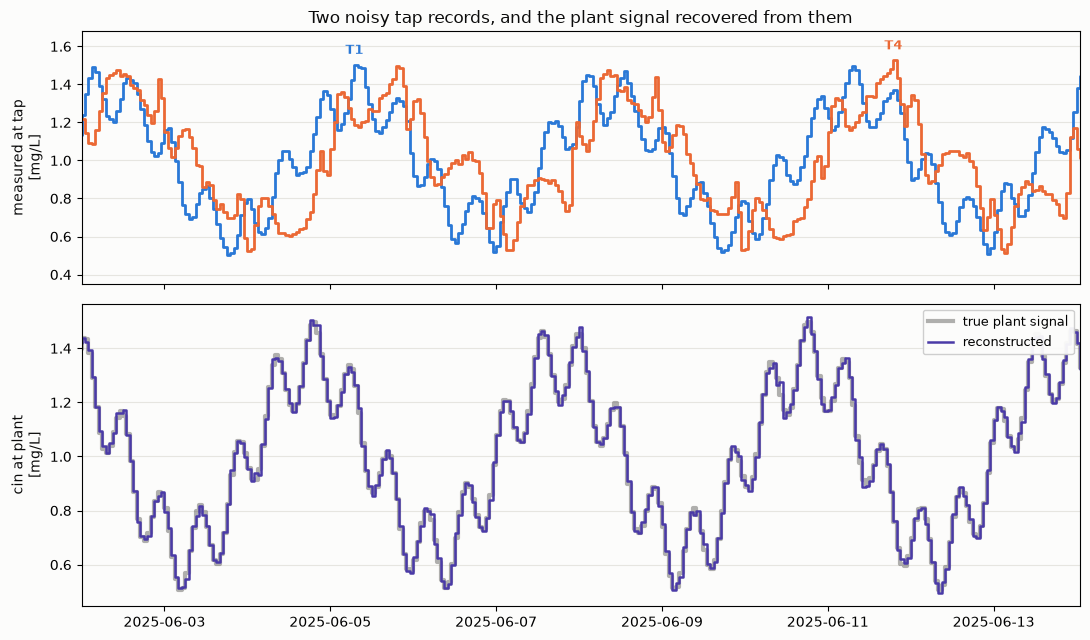

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True, height_ratios=[1, 1.2])

plot.endmember_series(values=measured, tedges=tedges, labels=sampled, ylabel="measured at tap\n[mg/L]", ax=axes[0])
axes[0].set_title("Two noisy tap records, and the plant signal recovered from them", fontsize=12, color=INK)
axes[0].get_legend().remove()

axes[1].plot(*step_plot_coords(tedges, true_cin), color=INK_SOFT, linewidth=3, alpha=0.45, label="true plant signal")
axes[1].plot(*step_plot_coords(tedges, recovered), color="#4a3aa7", linewidth=1.8, label="reconstructed")
axes[1].set_ylabel("cin at plant\n[mg/L]", color=INK)
axes[1].grid(visible=True, axis="y", color="#e6e5e0", linewidth=0.8)
axes[1].set_axisbelow(True)
axes[1].set_xlim(tedges[24], tedges[-24])
axes[1].legend(loc="upper right", fontsize=9, framealpha=0.95)

plt.tight_layout()
plt.show()

The reconstruction tracks the 72-hour swing and most of the 11-hour ripple, at an error comparable
to the measurement noise. It degrades at both ends of the record, where no tap measurement reaches
back far enough to constrain the production — those bins come back as `NaN` rather than as a
plausible-looking guess.

Two levers matter in practice. `regularization_strength` sets how much the solver trusts the data
against a smooth reference; $(\sigma_\text{noise}/\sigma_\text{signal})^2$ is a good starting
point. And the choice of sampling points sets *which* history is constrained: T1 and T4 have
mean travel times about eight hours apart, so together they pin down a wider window than two taps
on the same district main would.

## 7. Scope and limitations

The model is exact for a single-source tree under plug flow. Five things fall outside it.

- **Merging flows.** A loop, or a second treatment plant, blends two transport histories at a
  node. A single-`cin` model has no way to express that. `PipeNetwork` refuses such a graph rather
  than approximating it.
- **Storage.** A tank is a mixing volume, not a queue. A well-mixed tank has an exponential
  residence-time distribution rather than a delay, so it needs a different element.
- **Flow reversal.** Every segment must carry non-negative flow; a demand pattern that reverses a
  district main is out of scope.
- **Dispersion.** Turbulent mains approach plug flow well. Small-diameter, low-flow service lines
  are laminar and smear a pulse considerably, so an arrival predicted here is the *earliest*
  plausible one for such a branch — useful as a conservative bound for a contamination event, less
  so for matching a measured breakthrough curve.
- **Demand allocation.** Demand is drawn at the endmembers. Real mains lose water along their
  length to house connections, which shortens the effective travel time of the far end.

Within those bounds nothing is approximated: the arrival map, the flow-weighted bin average and
the decay integral are all evaluated in closed form, and the package reproduces the
$\sum V_i/f_i$ closed form to machine precision whenever the demands do happen to move in
proportion.